In [2]:
using Pkg; Pkg.activate(".")
using Revise

using NCDatasets
using PythonPlot

  Activating project at `~/Projects/lidar/ASTRAL2024`
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/CondaPkg/XVjyK/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonCall/1cbNR/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonPlot/oS8x4/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonCall/83z4q/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/CondaPkg/8GjrP/CondaPkg.toml
    CondaPkg Dependencies already up to date


In [ ]:
# load 4-30 mean wind data
UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240430_v1.nc")) # lidar wind NCDataset
(keys(UV), ) # :time, :z_range, :ur, :vr, :ut, :vt

# load PSL met data from a candidate file, in order of preference...
pslfiles = [ "/mnt/c/Users/deszoeks/Data/EKAMSAT/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "~/Data/ASTRAL/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "/Users/deszoeks/Projects/ASTRAL/SSTcompare/data/PSL/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc",
          "/Users/deszoeks/Projects/ASTRAL/mast/data/SSTcompare/PSL/netcdf/ASTRAL-nav-met-sea-flux-10min_RV-Thompson_20240428_R1_thru_20240613.nc" ]
psl = NCDataset(pslfiles[findfirst(isfile, pslfiles)])


(["time", "z_range", "lat", "lon", "ut", "vt", "bs", "snr", "umet", "vmet", "ur", "vr", "usog", "vsog"],)

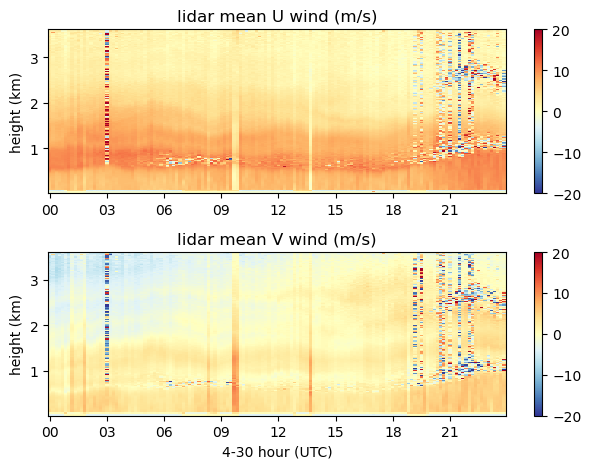

In [18]:
# plot lidar mean UV for 2024-04-30
clf()
subplot(2,1,1)
# pcolormesh(UV[:time], UV[:z_range], UV[:ur][:,:]', cmap=ColorMap("RdYlBu_r"), vmin=-20, vmax=20)
pcolormesh(UV[:time], UV[:z_range]/1e3, UV[:ut][:,:]', cmap=ColorMap("RdYlBu_r"), vmin=-20, vmax=20)
colorbar()
gca().set_facecolor("gray")
gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H"))
ylabel("height (km)")
title("lidar mean U wind (m/s)")

subplot(2,1,2)
# pcolormesh(UV[:time], UV[:z_range], UV[:vr][:,:]', cmap=ColorMap("RdYlBu_r"), vmin=-20, vmax=20)
pcolormesh(UV[:time], UV[:z_range]/1e3, UV[:vt][:,:]', cmap=ColorMap("RdYlBu_r"), vmin=-20, vmax=20)
colorbar()
gca().set_facecolor("gray")
gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H"))
gcf()
xlabel("4-30 hour (UTC)")
ylabel("height (km)")
title("lidar mean V wind (m/s)")
tight_layout()
gcf()

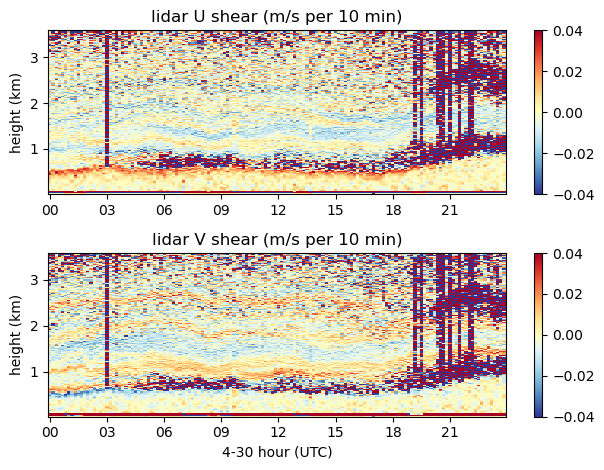

In [17]:
# plot lidar mean UV - has lots of gaps!
dz = diff(UV[:z_range])

clf()
subplot(2,1,1)
# pcolormesh(UV[:time], UV[:z_range], UV[:ur][:,:]', cmap=ColorMap("RdYlBu_r"), vmin=-20, vmax=20)
pcolormesh(UV[:time], UV[:z_range][1:end-1]/1e3, diff(UV[:ut][:,:], dims=2)'/dz[1], cmap=ColorMap("RdYlBu_r"), vmin=-0.04, vmax=0.04)
colorbar()
gca().set_facecolor("gray")
gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H"))
ylabel("height (km)")
title("lidar U shear (m/s per 10 min)")

subplot(2,1,2)
# pcolormesh(UV[:time], UV[:z_range], UV[:vr][:,:]', cmap=ColorMap("RdYlBu_r"), vmin=-20, vmax=20)
pcolormesh(UV[:time], UV[:z_range][1:end-1]/1e3, diff(UV[:vt][:,:], dims=2)'/dz[1], cmap=ColorMap("RdYlBu_r"), vmin=-0.04, vmax=0.04)
colorbar()
gca().set_facecolor("gray")
gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H"))
ylabel("height (km)")
xlabel("4-30 hour (UTC)")
title("lidar V shear (m/s per 10 min)")

tight_layout()
gcf()